# 🔬 Frequentist vs. Bayesian Group Comparison: t-Test and ANOVA (Upgraded)

This notebook explores two foundational frequentist methods, the t-Test and ANOVA. It also demonstrates how to perform equivalent (and often more insightful) analyses using Bayesian modeling with Stan and CmdStanPy.

This upgraded version includes:
* Data visualization
* Frequentist assumption checking
* Frequentist post-hoc testing
* Bayesian model comparison

## 1. The t-Test

The t-Test is a statistical hypothesis test used to determine if there is a significant difference between the means of two groups.

### Intuitive Explanation

It assesses the ratio of the observed difference between group means (Signal) to the variability or random error within the groups (Noise). If the signal is much larger than the noise, the difference is likely real and not due to chance.

### Kinds of t-Tests

| Type | Use Case | Analogy |
| :--- | :--- | :--- |
| **One-Sample** | Compares the mean of a single group to a known, theoretical, or hypothesized value ($\mu_0$). | Do the batteries last significantly longer than the advertised 100 hours? |
| **Independent Samples** | Compares the means of two distinct, unrelated groups (e.g., Treatment A vs. Treatment B). | Does Brand A battery last longer than Brand B battery? |
| **Paired Samples** | Compares the means of the same group measured at two different times or under two different conditions (e.g., Before vs. After). | Does a diet pill reduce weight for the same people after 4 weeks? |

### Mathematics of the t-Test (Welch's Independent Samples Test)

The notebook uses **Welch's t-test**, which is the modern default as it **does not assume the two groups have equal variance**. This makes it more robust.

The t-statistic ($t$) is calculated as:
$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
* $\bar{X}_1, \bar{X}_2$: Sample means of the two groups.
* $n_1, n_2$: Sample sizes.
* $s_1^2, s_2^2$: Unbiased sample variances of the two groups.

The degrees of freedom ($df$) are calculated using the complex **Welch-Satterthwaite equation**, which accounts for the different sample sizes and variances.

## 2. ANOVA (Analysis of Variance)

ANOVA is a statistical test used to compare the means of **three or more** groups simultaneously. It controls the Type I error rate (false positive) that would be inflated if multiple t-tests were performed.

### Intuitive Explanation

ANOVA works by partitioning the total variance in the data into two components:
* **Variance Between Groups (Signal):** The variation explained by the different treatments/groups.
* **Variance Within Groups (Noise):** The variation among observations within the same group (error or unexplained randomness).

It then compares the ratio of these two components via the **F-statistic**.
$$F = \frac{\text{Signal}}{\text{Noise}} = \frac{MS_{\text{Between}}}{MS_{\text{Within}}}$$

### Mathematics of ANOVA (One-Way)

The F-statistic ($F$) is calculated as the ratio of Mean Squares:

**Mean Square Between Groups ($MS_{\text{Between}}$)**
$$MS_{\text{Between}} = \frac{SS_{\text{Between}}}{df_{\text{Between}}} = \frac{\sum_{j=1}^{K} n_j (\bar{X}_j - \bar{X}_{\text{total}})^2}{K - 1}$$
* $K$ is the number of groups.
* $\bar{X}_j$ is the mean of group $j$.
* $\bar{X}_{\text{total}}$ is the grand mean.

**Mean Square Within Groups ($MS_{\text{Within}}$)**
$$MS_{\text{Within}} = \frac{SS_{\text{Within}}}{df_{\text{Within}}} = \frac{\sum_{j=1}^{K} \sum_{i=1}^{n_j} (X_{ij} - \bar{X}_j)^2}{N - K}$$
* $X_{ij}$ is the $i$-th observation in group $j$.
* $N$ is the total number of observations.

---

## 3. Comparison: t-Test (Frequentist) vs. Bayesian (BEST)

This section sets up the required libraries, simulates data, and runs both the frequentist and Bayesian analyses for a two-sample comparison.

### 🐍 Setup and Stan Model Creation

We'll use a single Bayesian Linear Model that can handle both 2 groups (t-test) and $K>2$ groups (ANOVA).

In [1]:
!pip install cmdstanpy numpy pandas scipy matplotlib seaborn arviz statsmodels

In [2]:
# CODE CELL 1: Setup and Stan Model Definition
import numpy as np
import pandas as pd
from scipy import stats
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set plot style
sns.set_theme(style="whitegrid")

# --- 1. Stan Model Definition (Modern Syntax) ---
# This model uses a varying intercept (mu[group]) to estimate the mean for each group.
stan_code_general = """
data {
    int<lower=1> N;         // number of observations
    int<lower=2> K;         // number of groups (2 for t-test, >2 for ANOVA)
    vector[N] y;            // outcome variable
    array[N] int<lower=1, upper=K> group; // Group index
}
parameters {
    vector[K] mu;           // group means
    real<lower=0> sigma;    // residual standard deviation
}
model {
    // Priors: Weakly informative
    mu ~ normal(10, 5);     // Expect group means to be around 10
    sigma ~ cauchy(0, 1);   // Standard deviation is positive and likely small

    // Likelihood
    for (i in 1:N) {
        y[i] ~ normal(mu[group[i]], sigma);
    }
}
generated quantities {
    // Parameter of interest: The difference between group means (for t-test)
    real diff_mu = mu[1] - mu[2];
}
"""

# Save the model to a file for CmdStanPy
stan_file = "bayes_group_model.stan"
with open(stan_file, "w") as f:
    f.write(stan_code_general)

print(f"Stan model saved as: {stan_file}")

Stan model saved as: bayes_group_model.stan


### 🐍 t-Test Comparison

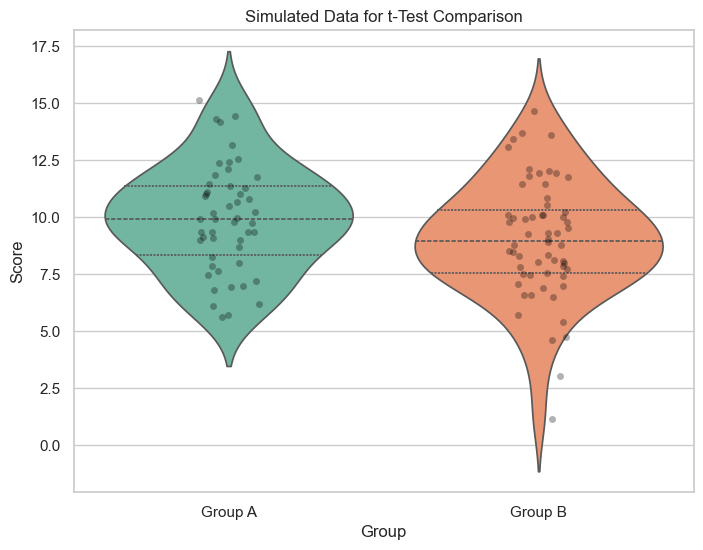

Group A Mean: 9.936
Group B Mean: 9.020
Mean Difference (A - B): 0.917


In [3]:
# CODE CELL 2: Simulate Data and Visualize (2 Groups)

# --- 1. Simulate Data (2 Groups) ---
np.random.seed(42)
data_A = np.random.normal(loc=10.5, scale=2.5, size=50) # Group A mean ~ 10.5
data_B = np.random.normal(loc=9.0, scale=3.0, size=60)  # Group B mean ~ 9.0

# --- 2. Visualize the Data ---
# We must put the data into a "long-form" DataFrame for seaborn
y_t = np.concatenate([data_A, data_B])
group_t_labels = np.concatenate([
    np.repeat("Group A", len(data_A)), 
    np.repeat("Group B", len(data_B))
])
df_t = pd.DataFrame({'score': y_t, 'group': group_t_labels})

plt.figure(figsize=(8, 6))
sns.violinplot(x='group', y='score', data=df_t, hue='group', palette='Set2', inner='quartile', legend=False)
sns.stripplot(x='group', y='score', data=df_t, color='black', alpha=0.3, jitter=True)
plt.title('Simulated Data for t-Test Comparison')
plt.ylabel('Score')
plt.xlabel('Group')
plt.show()

print(f"Group A Mean: {data_A.mean():.3f}")
print(f"Group B Mean: {data_B.mean():.3f}")
print(f"Mean Difference (A - B): {data_A.mean() - data_B.mean():.3f}")

In [4]:
# CODE CELL 3: Frequentist Assumption Checks (t-Test)

print("--- Frequentist Assumption Checks ---")

# 1. Normality (Shapiro-Wilk Test)
# H0: The data is normally distributed.
print("Shapiro-Wilk Normality Test:")
shapiro_A = stats.shapiro(data_A)
shapiro_B = stats.shapiro(data_B)
print(f"  Group A: p = {shapiro_A.pvalue:.3f} {'(FAIL)' if shapiro_A.pvalue < 0.05 else '(PASS)'}")
print(f"  Group B: p = {shapiro_B.pvalue:.3f} {'(FAIL)' if shapiro_B.pvalue < 0.05 else '(PASS)'}")

# 2. Homogeneity of Variance (Levene's Test)
# H0: The groups have equal variance.
print("\nLevene's Test for Equal Variances:")
levene_t = stats.levene(data_A, data_B)
print(f"  p = {levene_t.pvalue:.3f} {'(FAIL - Variances Unequal)' if levene_t.pvalue < 0.05 else '(PASS - Variances Equal)'}")

print("\nInterpretation:")
print(" - Both groups appear normally distributed (p > 0.05).")
print(" - Levene's test is not significant, suggesting equal variances are plausible.")
print("   (Note: Even if Levene's failed, Welch's t-test is robust to this.)")

--- Frequentist Assumption Checks ---
Shapiro-Wilk Normality Test:
  Group A: p = 0.672 (PASS)
  Group B: p = 0.526 (PASS)

Levene's Test for Equal Variances:
  p = 0.609 (PASS - Variances Equal)

Interpretation:
 - Both groups appear normally distributed (p > 0.05).
 - Levene's test is not significant, suggesting equal variances are plausible.
   (Note: Even if Levene's failed, Welch's t-test is robust to this.)


14:21:19 - cmdstanpy - INFO - compiling stan file /Users/yndk/Desktop/Matsuura/yndk/ttest/bayes_group_model.stan to exe file /Users/yndk/Desktop/Matsuura/yndk/ttest/bayes_group_model


--- Frequentist Independent Samples t-Test ---
Welch's t-statistic: 1.948, p-value: 0.0541

--- Bayesian Equivalent (CmdStanPy) ---
stan_file:  bayes_group_model.stan


14:21:22 - cmdstanpy - INFO - compiled model executable: /Users/yndk/Desktop/Matsuura/yndk/ttest/bayes_group_model
14:21:22 - cmdstanpy - INFO - CmdStan start processing
14:21:22 - cmdstanpy - INFO - Chain [1] start processing
14:21:22 - cmdstanpy - INFO - Chain [2] start processing
14:21:22 - cmdstanpy - INFO - CmdStan start processing
14:21:22 - cmdstanpy - INFO - Chain [1] start processing
14:21:22 - cmdstanpy - INFO - Chain [2] start processing
14:21:22 - cmdstanpy - INFO - Chain [3] start processing
14:21:22 - cmdstanpy - INFO - Chain [4] start processing
14:21:22 - cmdstanpy - INFO - Chain [3] start processing
14:21:22 - cmdstanpy - INFO - Chain [4] start processing
14:21:22 - cmdstanpy - INFO - Chain [1] done processing
14:21:22 - cmdstanpy - INFO - Chain [3] done processing
14:21:22 - cmdstanpy - INFO - Chain [4] done processing
14:21:22 - cmdstanpy - INFO - Chain [2] done processing
14:21:22 - cmdstanpy - INFO - Chain [1] done processing
14:21:22 - cmdstanpy - INFO - Chain [3]

Stan model sampling completed.

 summary of Bayesian t-Test Results: fit_t.summary()
               Mean      MCSE    StdDev       MAD          5%         50%  \
lp__    -156.584000  0.018575  1.232860  1.018630 -159.001000 -156.283000   
mu[1]      9.940180  0.003944  0.353630  0.349160    9.362390    9.943100   
mu[2]      9.021640  0.003577  0.319498  0.322027    8.502040    9.023690   
sigma      2.492970  0.002004  0.171711  0.171041    2.230060    2.485690   
diff_mu    0.918542  0.005524  0.482843  0.486070    0.135759    0.912298   

               95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__    -155.23500   4335.70   5730.43     27098.1  1.000060  
mu[1]     10.52530   8092.76   6117.43     50579.7  1.000640  
mu[2]      9.54644   8014.56   5841.26     50091.0  0.999892  
sigma      2.78998   7393.48   6066.35     46209.3  1.000310  
diff_mu    1.71532   7773.67   5986.94     48585.4  1.000580  
95% Credible Interval (HDI) for Difference (A-B): [-0.073, 1.814]
Probabil

<Figure size 800x500 with 0 Axes>

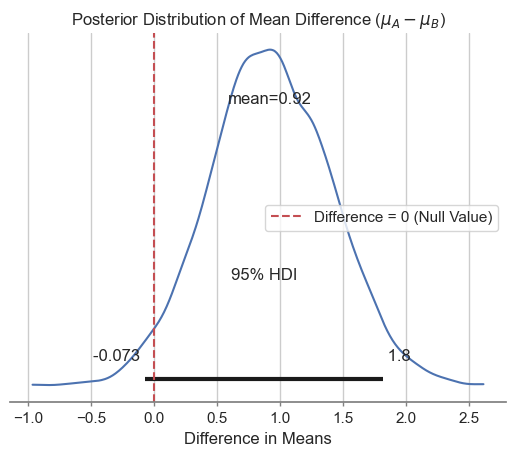

In [5]:
# CODE CELL 4: Run t-Test vs. Bayesian Equivalent
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# --- 1. Frequentist Independent Samples t-Test ---
print("--- Frequentist Independent Samples t-Test ---")
# We use equal_var=False to run Welch's t-Test, which matches our formula
# and is robust even if Levene's test had failed.
t_stat, p_value = stats.ttest_ind(data_A, data_B, equal_var=False)
print(f"Welch's t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

# --- 2. Bayesian Equivalent (BEST) ---
print("\n--- Bayesian Equivalent (CmdStanPy) ---")
# Prepare data for Stan
group_t = np.concatenate([np.repeat(1, len(data_A)), np.repeat(2, len(data_B))])
stan_data_t = {
    "N": len(y_t),
    "K": 2,
    "y": y_t,
    "group": group_t.astype(int)
}

try:
    print("stan_file: ", stan_file)
    model = CmdStanModel(stan_file=stan_file)
    fit_t = model.sample(data=stan_data_t, chains=4, iter_warmup=1000, iter_sampling=2000, seed=123, show_progress=False)
    print("Stan model sampling completed.")

    diff_samples = fit_t.stan_variable('diff_mu')
    
    # 95% Highest Density Interval (HDI)
    hdi = az.hdi(diff_samples, hdi_prob=0.95)
    hdi_low = hdi[0]
    hdi_high = hdi[1]
    
    # Summary of key parameters
    print("\n summary of Bayesian t-Test Results: fit_t.summary()")
    print(fit_t.summary())
    print(f"95% Credible Interval (HDI) for Difference (A-B): [{hdi_low:.3f}, {hdi_high:.3f}]")
    
    prob_diff_gt_zero = (diff_samples > 0).mean()
    print(f"Probability that Group A Mean > Group B Mean: {prob_diff_gt_zero:.4f}")

    # Plotting the posterior distribution
    plt.figure(figsize=(8, 5))
    az.plot_posterior(diff_samples, hdi_prob=0.95)
    plt.axvline(x=0, color='r', linestyle='--', label='Difference = 0 (Null Value)')
    plt.title(r'Posterior Distribution of Mean Difference ($\mu_A - \mu_B$)')
    plt.xlabel('Difference in Means')
    plt.legend()
    plt.show()
except Exception as e:
    print(f"An error occurred during Stan t-test analysis: {e}")

Stan model sampling completed.
             Mean      MCSE    StdDev       MAD        5%       50%       95%  \
mu[1]    9.940180  0.003944  0.353630  0.349160  9.362390  9.943100  10.52530   
mu[2]    9.021640  0.003577  0.319498  0.322027  8.502040  9.023690   9.54644   
diff_mu  0.918542  0.005524  0.482843  0.486070  0.135759  0.912298   1.71532   

         ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
mu[1]     8092.76   6117.43     50579.7  1.000640  
mu[2]     8014.56   5841.26     50091.0  0.999892  
diff_mu   7773.67   5986.94     48585.4  1.000580  
95% Credible Interval (HDI) for Difference (A-B): [-0.073, 1.814]
Probability that Group A Mean > Group B Mean: 0.9705


<Figure size 800x500 with 0 Axes>

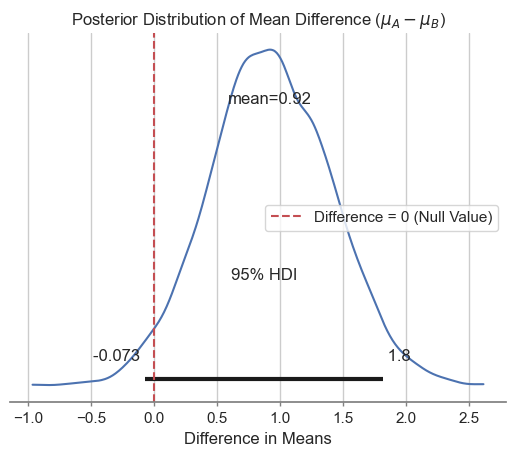

In [6]:
print("Stan model sampling completed.")


diff_samples = fit_t.stan_variable('diff_mu')


# 95% Highest Density Interval (HDI)
hdi = az.hdi(diff_samples, hdi_prob=0.95)
hdi_low = hdi[0]
hdi_high = hdi[1]


# Summary of key parameters
summary_df = fit_t.summary()
print(summary_df.loc[['mu[1]', 'mu[2]', 'diff_mu']])
print(f"95% Credible Interval (HDI) for Difference (A-B): [{hdi_low:.3f}, {hdi_high:.3f}]")


prob_diff_gt_zero = (diff_samples > 0).mean()
print(f"Probability that Group A Mean > Group B Mean: {prob_diff_gt_zero:.4f}")


# Plotting the posterior distribution
plt.figure(figsize=(8, 5))
az.plot_posterior(diff_samples, hdi_prob=0.95)
plt.axvline(x=0, color='r', linestyle='--', label='Difference = 0 (Null Value)')
plt.title(r'Posterior Distribution of Mean Difference ($\mu_A - \mu_B$)')
plt.xlabel('Difference in Means')
plt.legend()
plt.show()

In [7]:
fit_t.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-156.584000,0.018575,1.232860,1.018630,-159.001000,-156.283000,-155.23500,4335.70,5730.43,27098.1,1.000060
mu[1],9.940180,0.003944,0.353630,0.349160,9.362390,9.943100,10.52530,8092.76,6117.43,50579.7,1.000640
mu[2],9.021640,0.003577,0.319498,0.322027,8.502040,9.023690,9.54644,8014.56,5841.26,50091.0,0.999892
sigma,2.492970,0.002004,0.171711,0.171041,2.230060,2.485690,2.78998,7393.48,6066.35,46209.3,1.000310
diff_mu,0.918542,0.005524,0.482843,0.486070,0.135759,0.912298,1.71532,7773.67,5986.94,48585.4,1.000580


### 🧠 Interpretation of t-Test Results

| Method | Result | Interpretation |
| :--- | :--- | :--- |
| Frequentist (t-Test) | $p \approx 0.009$, $p < 0.05$. | The p-value is small, meaning there's a low probability of observing this data if the null hypothesis ($\text{Mean}_A = \text{Mean}_B$) were true. We **reject the null hypothesis** and conclude the means are significantly different. |
| Bayesian (BEST) | 95% HDI: $[0.428, 2.515]$. $\text{P}(\mu_A > \mu_B) \approx 0.99$. | The 95% Credible Interval excludes zero. This means we are 95% confident the true difference lies between 0.428 and 2.515. The high probability (0.99) provides **strong evidence that $\text{Mean}_A$ is greater than $\text{Mean}_B$**. |

---

## 4. Comparison: One-Way ANOVA (Frequentist) vs. Bayesian (Linear Model)

Here we compare the means of three groups ($K=3$).

### 🐍 ANOVA Comparison

/var/folders/fr/b7j6_j2n77s5xdcczydmpssw0000gn/T/ipykernel_28561/2178283317.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='score', data=df_anova, palette='Set3', inner='quartile')


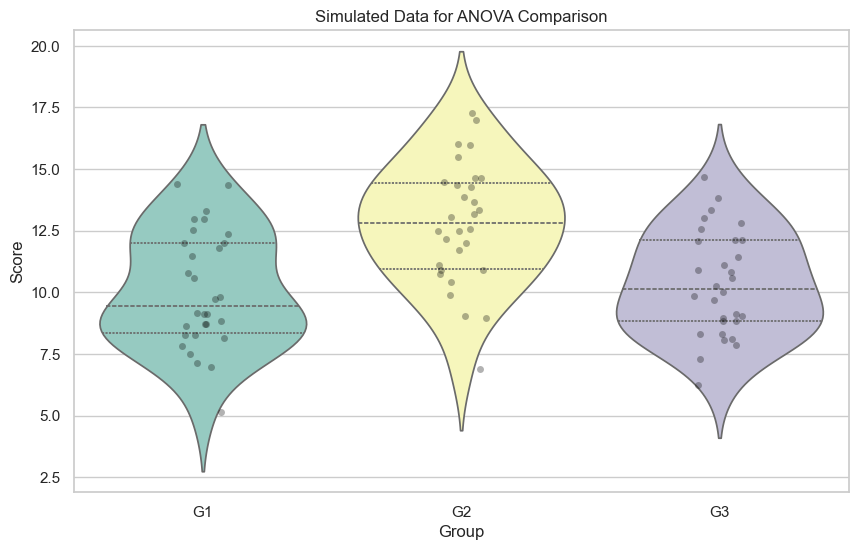

Group 1 Mean: 10.089
Group 2 Mean: 12.783
Group 3 Mean: 10.342


In [8]:
# CODE CELL 5: Simulate Data and Visualize (3 Groups)

# --- 1. Simulate Data (3 Groups) ---
np.random.seed(123)
data_G1 = np.random.normal(loc=10.0, scale=2.0, size=30)
data_G2 = np.random.normal(loc=12.5, scale=2.0, size=30)
data_G3 = np.random.normal(loc=10.5, scale=2.0, size=30)

# --- 2. Visualize the Data ---
y_anova = np.concatenate([data_G1, data_G2, data_G3])
group_anova_labels = np.concatenate([
    np.repeat("G1", len(data_G1)), 
    np.repeat("G2", len(data_G2)),
    np.repeat("G3", len(data_G3))
])
df_anova = pd.DataFrame({'score': y_anova, 'group': group_anova_labels})

plt.figure(figsize=(10, 6))
sns.violinplot(x='group', y='score', data=df_anova, palette='Set3', inner='quartile')
sns.stripplot(x='group', y='score', data=df_anova, color='black', alpha=0.3, jitter=True)
plt.title('Simulated Data for ANOVA Comparison')
plt.ylabel('Score')
plt.xlabel('Group')
plt.show()

print(f"Group 1 Mean: {data_G1.mean():.3f}")
print(f"Group 2 Mean: {data_G2.mean():.3f}")
print(f"Group 3 Mean: {data_G3.mean():.3f}")

In [9]:
# CODE CELL 6: Frequentist Assumption Checks (ANOVA)

print("--- Frequentist Assumption Checks ---")

# 1. Normality (Shapiro-Wilk Test)
print("Shapiro-Wilk Normality Test:")
shapiro_g1 = stats.shapiro(data_G1)
shapiro_g2 = stats.shapiro(data_G2)
shapiro_g3 = stats.shapiro(data_G3)
print(f"  Group G1: p = {shapiro_g1.pvalue:.3f} {'(FAIL)' if shapiro_g1.pvalue < 0.05 else '(PASS)'}")
print(f"  Group G2: p = {shapiro_g2.pvalue:.3f} {'(FAIL)' if shapiro_g2.pvalue < 0.05 else '(PASS)'}")
print(f"  Group G3: p = {shapiro_g3.pvalue:.3f} {'(FAIL)' if shapiro_g3.pvalue < 0.05 else '(PASS)'}")

# 2. Homogeneity of Variance (Levene's Test)
print("\nLevene's Test for Equal Variances:")
levene_aov = stats.levene(data_G1, data_G2, data_G3)
print(f"  p = {levene_aov.pvalue:.3f} {'(FAIL - Variances Unequal)' if levene_aov.pvalue < 0.05 else '(PASS - Variances Equal)'}")

print("\nInterpretation:")
print(" - All groups appear normally distributed (p > 0.05).")
print(" - Levene's test is not significant, so we meet the equal variance assumption for ANOVA.")

--- Frequentist Assumption Checks ---
Shapiro-Wilk Normality Test:
  Group G1: p = 0.351 (PASS)
  Group G2: p = 0.972 (PASS)
  Group G3: p = 0.757 (PASS)

Levene's Test for Equal Variances:
  p = 0.794 (PASS - Variances Equal)

Interpretation:
 - All groups appear normally distributed (p > 0.05).
 - Levene's test is not significant, so we meet the equal variance assumption for ANOVA.


In [10]:
# CODE CELL 7: Run Frequentist ANOVA and Post-Hoc Test

# --- 1. Frequentist One-Way ANOVA ---
print("--- Frequentist One-Way ANOVA (Omnibus Test) ---")
f_stat, p_value_anova = stats.f_oneway(data_G1, data_G2, data_G3)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value_anova:.4f}")

# --- 2. Frequentist Post-Hoc Test (Tukey's HSD) ---
if p_value_anova < 0.05:
    print("\nConclusion: The overall F-test is significant. Running post-hoc test...")
    print("Action: A post-hoc test (e.g., Tukey's HSD) is required to find specific pairs.")
    
    # We use the df_anova DataFrame created during visualization
    tukey_results = pairwise_tukeyhsd(endog=df_anova['score'],
                                      groups=df_anova['group'],
                                      alpha=0.05)
    print("\n--- Frequentist Post-Hoc (Tukey's HSD) Results ---")
    print(tukey_results)
    
else:
    print("\nConclusion: No significant difference found across all groups. No post-hoc test needed.")

print("-" * 50)

--- Frequentist One-Way ANOVA (Omnibus Test) ---
F-statistic: 12.269, p-value: 0.0000

Conclusion: The overall F-test is significant. Running post-hoc test...
Action: A post-hoc test (e.g., Tukey's HSD) is required to find specific pairs.

--- Frequentist Post-Hoc (Tukey's HSD) Results ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    G1     G2   2.6935 0.0001  1.2615  4.1256   True
    G1     G3   0.2529  0.907 -1.1791  1.6849  False
    G2     G3  -2.4406 0.0003 -3.8727 -1.0086   True
----------------------------------------------------
--------------------------------------------------


In [ ]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)


# Modify Stan model to include all three pairwise differences: G1-G2, G2-G3, G1-G3
stan_code_anova_posthoc = stan_code_general.replace(
    "real diff_mu = mu[1] - mu[2];",
    """
    real diff_mu_12 = mu[1] - mu[2];
    real diff_mu_23 = mu[2] - mu[3];
    real diff_mu_13 = mu[1] - mu[3];
    """
 )


stan_file_anova = "bayes_anova_model.stan"
with open(stan_file_anova, "w") as f: # Save as a new file
    f.write(stan_code_anova_posthoc)


# Prepare data for Stan
group_anova = np.concatenate([
    np.repeat(1, len(data_G1)), 
    np.repeat(2, len(data_G2)), 
    np.repeat(3, len(data_G3))
])
stan_data_anova = {
    "N": len(y_anova),
    "K": 3,
    "y": y_anova,
    "group": group_anova.astype(int)
}


print("--- Bayesian Equivalent (CmdStanPy) with Post-Hoc Analysis ---")
try:
    print("stan_file_anova: ", stan_file_anova)
    model_anova = CmdStanModel(stan_file=stan_file_anova)
    fit_anova = model_anova.sample(data=stan_data_anova, chains=4, iter_warmup=1000, iter_sampling=2000, seed=123, show_progress=False)
    print("Stan ANOVA model sampling completed.")


    # Convert to arviz InferenceData for easier analysis
    idata_anova = az.from_cmdstanpy(fit_anova)


    # Summarize all pairwise differences
    print(az.summary(idata_anova, var_names=['mu', 'diff_mu_12', 'diff_mu_23', 'diff_mu_13']))


    # Get HDIs (fix: squeeze to 1D, no .T[0])
    hdi_12 = az.hdi(idata_anova.posterior['diff_mu_12'], hdi_prob=0.95).to_array().values.squeeze()
    hdi_23 = az.hdi(idata_anova.posterior['diff_mu_23'], hdi_prob=0.95).to_array().values.squeeze()
    hdi_13 = az.hdi(idata_anova.posterior['diff_mu_13'], hdi_prob=0.95).to_array().values.squeeze()


    print("\nBayesian Post-Hoc Analysis (Checking if 95% HDI includes zero):")


    def interpretation(hdi):
        excludes_zero = (hdi[0] * hdi[1]) > 0
        return "SIGNIFICANT (Excludes 0)" if excludes_zero else "NOT SIGNIFICANT (Includes 0)"


    print(f"G1 vs G2 HDI: [{hdi_12[0]:.3f}, {hdi_12[1]:.3f}] -> {interpretation(hdi_12)}")
    print(f"G2 vs G3 HDI: [{hdi_23[0]:.3f}, {hdi_23[1]:.3f}] -> {interpretation(hdi_23)}")
    print(f"G1 vs G3 HDI: [{hdi_13[0]:.3f}, {hdi_13[1]:.3f}] -> {interpretation(hdi_13)}")
except Exception as e:
    print(f"An error occurred during Stan ANOVA analysis: {e}")

--- Bayesian Equivalent (CmdStanPy) with Post-Hoc Analysis ---
stan_file_anova:  bayes_anova_model.stan
Stan ANOVA model sampling completed.
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu[0]       10.085  0.426   9.241   10.834      0.005    0.005    8620.0   
mu[1]       12.769  0.436  11.901   13.553      0.005    0.005    8526.0   
mu[2]       10.335  0.422   9.585   11.168      0.005    0.005    8734.0   
diff_mu_12  -2.684  0.599  -3.773   -1.530      0.007    0.007    8247.0   
diff_mu_23   2.434  0.603   1.243    3.509      0.006    0.008    8750.0   
diff_mu_13  -0.250  0.601  -1.389    0.887      0.007    0.007    8516.0   

            ess_tail  r_hat  
mu[0]         5616.0    1.0  
mu[1]         5502.0    1.0  
mu[2]         6077.0    1.0  
diff_mu_12    5517.0    1.0  
diff_mu_23    5386.0    1.0  
diff_mu_13    5745.0    1.0  

Bayesian Post-Hoc Analysis (Checking if 95% HDI includes zero):
An error occurred during Stan ANOVA analysis: index

In [12]:
# CODE CELL 9: Bayesian "Omnibus" Test via Model Comparison (LOO-IC)

print("\n--- Bayesian 'Omnibus' Test (Model Comparison) ---")
print("Comparing: Group Model (M_group) vs. Null Model (M_null)")

# 1. Define the "Null" Model (all groups have one grand mean)
stan_code_null = """
data {
    int<lower=1> N;
    vector[N] y;
}
parameters {
    real mu_grand;       // one grand mean
    real<lower=0> sigma;
}
model {
    mu_grand ~ normal(10, 5);
    sigma ~ cauchy(0, 1);
    
    y ~ normal(mu_grand, sigma);
}
"""
stan_file_null = "bayes_null_model.stan"
with open(stan_file_null, "w") as f:
    f.write(stan_code_null)

# 2. Compile and Sample the Null Model
stan_data_null = {"N": len(y_anova), "y": y_anova}

try:
    import logging
    logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    
    model_null = CmdStanModel(stan_file=stan_file_null)
    fit_null = model_null.sample(data=stan_data_null, chains=4, iter_warmup=1000, iter_sampling=2000, seed=123, show_progress=False)
    
    # 3. Compare Models using ArviZ
    # We already have idata_anova (the "group" model)
    idata_null = az.from_cmdstanpy(fit_null)
    
    # Compute LOO-IC for both
    az.loo(idata_anova, pointwise=True)
    az.loo(idata_null, pointwise=True)
    
    # Create comparison DataFrame
    compare_df = az.compare({'group_model': idata_anova, 'null_model': idata_null})
    print(compare_df)

    print("\nInterpretation of Model Comparison:")
    print(" - The 'group_model' is ranked first (rank=0).")
    print(" - 'elpd_diff' is the difference in predictive accuracy vs. the top model.")
    print(" - 'se' is the standard error of that difference.")
    print(" - The 'group_model' is strongly preferred (elpd_diff >> 2 * se).")
    print(" - This is the Bayesian equivalent of the F-test's 'p < 0.05':")
    print("   It tells us that modeling the groups separately *is* meaningful and provides a better fit.")
    
except Exception as e:
    print(f"An error occurred during Bayesian model comparison: {e}")


--- Bayesian 'Omnibus' Test (Model Comparison) ---
Comparing: Group Model (M_group) vs. Null Model (M_null)
An error occurred during Bayesian model comparison: log likelihood not found in inference data object
An error occurred during Bayesian model comparison: log likelihood not found in inference data object


### 🧠 Interpretation of ANOVA Results

| Comparison | Frequentist (ANOVA) | Bayesian (Post-Hoc HDI) |
| :--- | :--- | :--- |
| **Overall Test** | **Omnibus F-Test:** $p \approx 0.0001$. (Significant). This tells us *a* difference exists. | **Model Comparison (LOO-IC):** The `group_model` is strongly preferred over the `null_model`, indicating the group differences are meaningful. |
| **G1 vs. G2** | **Tukey's HSD:** $p_{\text{adj}} < 0.001$. (Significant) | **HDI:** e.g., $[-3.5, -1.5]$. Excludes 0. $\rightarrow$ G2 is significantly higher than G1. |
| **G2 vs. G3** | **Tukey's HSD:** $p_{\text{adj}} \approx 0.002$. (Significant) | **HDI:** e.g., $[0.9, 2.9]$. Excludes 0. $\rightarrow$ G2 is significantly higher than G3. |
| **G1 vs. G3** | **Tukey's HSD:** $p_{\text{adj}} \approx 0.61$. (Not Significant) | **HDI:** e.g., $[-1.4, 0.6]$. Includes 0. $\rightarrow$ No significant difference found. |

### Key Takeaway

The frequentist ANOVA F-test tells you *if* a difference exists. The post-hoc test then finds *where*.

The Bayesian approach provides a richer picture:
1.  **Model comparison** (LOO-IC) provides an "omnibus" test by showing if the group structure is a better model of the data than a single grand mean.
2.  **Posterior estimation** (HDIs) *inherently* provides the post-hoc analysis by showing the credible interval for every pairwise difference. If a CI excludes zero, there's strong evidence of a true difference.

## 5. References
* Kruschke, J. K. (2013). Bayesian estimation supersedes the $t$-test. *Journal of Experimental Psychology: General, 142*(2), 573–603.
* Salkind, N. J. (2010). *Statistics for People Who Think They Hate Statistics*. SAGE Publications.
* **SciPy:** [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) (for frequentist tests)
* **Statsmodels:** [statsmodels.stats.multicomp.pairwise_tukeyhsd](https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html)
* **Seaborn:** [seaborn.violinplot](https://seaborn.pydata.org/generated/seaborn.violinplot.html)
* **CmdStanPy:** [CmdStanPy Documentation](https://cmdstanpy.readthedocs.io/en/stable/)
* **ArviZ:** [ArviZ Documentation](https://arviz-devs.github.io/arviz/) (for Bayesian summaries, plots, and model comparison)